# Assignment 1 Code

The objective of this assignment is to understand and apply data preprocessing techniques on a
dataset. You will learn how to clean, transform, and prepare data for modeling, focusing on various
steps involved in data preprocessing such as handling missing values, encoding categorical data,
feature scaling, and data splitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from toolbox.plotting import Style
style_assignment_1 = Style(main_theme=Style.MainTheme.LIGHT)

### Data

You are free to choose your datasets (you might need more than one) for this assignment. You have
to use the datasets that are uploaded to blackboard.

In [39]:
df_1 = pd.read_csv('data/smoking_drinking_dataset_ver01_1.csv', index_col='Unnamed: 0')
df_2 = pd.read_csv('data/smoking_drinking_dataset_ver01_2.csv', index_col='Unnamed: 0')

In [40]:
df = pd.concat([df_1, df_2])

### Data Exploration (10%)

- Explore the dataset by displaying the first few rows, summary statistics, and data types of each column.
- Identify missing values, outliers, and unique values in categorical columns.

In [41]:
print(df.shape)
print(df.size)

(991346, 24)
23792304


In [42]:
df.columns

Index(['sex', 'age', 'height', 'weight', 'waistline', 'sight_left',
       'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS',
       'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin',
       'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT',
       'gamma_GTP', 'SMK_stat_type_cd', 'DRK_YN'],
      dtype='object')

In [43]:
df.head(10)

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,80.0,99.0,193.0,48.0,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,82.0,106.0,228.0,55.0,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,70.0,98.0,136.0,41.0,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,87.0,95.0,201.0,76.0,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,82.0,101.0,199.0,61.0,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
5,Male,50,165,55,75.0,1.2,1.5,1.0,1.0,142.0,92.0,99.0,218.0,77.0,95.0,232.0,13.8,3.0,0.8,29.0,40.0,37.0,3.0,Y
6,Female,45,150,55,69.0,0.5,0.4,1.0,1.0,101.0,58.0,89.0,196.0,66.0,115.0,75.0,12.3,1.0,0.8,19.0,12.0,12.0,1.0,N
7,Male,35,175,65,84.2,1.2,1.0,1.0,1.0,132.0,80.0,94.0,185.0,58.0,107.0,101.0,14.4,1.0,0.8,18.0,18.0,35.0,3.0,Y
8,Male,55,170,75,84.0,1.2,0.9,1.0,1.0,145.0,85.0,104.0,217.0,56.0,141.0,100.0,15.1,1.0,0.8,32.0,23.0,26.0,1.0,Y
9,Male,40,175,75,82.0,1.5,1.5,1.0,1.0,132.0,105.0,100.0,195.0,60.0,118.0,83.0,13.9,1.0,0.9,21.0,38.0,16.0,2.0,Y


In [44]:
df.describe()

,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd
count,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000
mean,47.614491,162.240625,63.284050,81.233358,0.980834,0.978429,1.031495,1.030476,122.432498,76.052627,100.424447,195.557020,56.936800,113.037692,132.141751,14.229824,1.094224,0.860467,25.989308,25.755051,37.136347,1.608122
std,14.181339,9.282957,12.514241,11.850323,0.605949,0.604774,0.174650,0.171892,14.543148,9.889365,24.179960,38.660155,17.238479,35.842812,102.196985,1.584929,0.437724,0.480530,23.493386,26.308599,50.424153,0.818507
min,20.000000,130.000000,25.000000,8.000000,0.100000,0.100000,1.000000,1.000000,67.000000,32.000000,25.000000,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.100000,1.000000,1.000000,1.000000,1.000000
25%,35.000000,155.000000,55.000000,74.100000,0.700000,0.700000,1.000000,1.000000,112.000000,70.000000,88.000000,169.000000,46.000000,89.000000,73.000000,13.200000,1.000000,0.700000,19.000000,15.000000,16.000000,1.000000
50%,45.000000,160.000000,60.000000,81.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,96.000000,193.000000,55.000000,111.000000,106.000000,14.300000,1.000000,0.800000,23.000000,20.000000,23.000000,1.000000
75%,60.000000,170.000000,70.000000,87.800000,1.200000,1.200000,1.000000,1.000000,131.000000,82.000000,105.000000,219.000000,66.000000,135.000000,159.000000,15.400000,1.000000,1.000000,28.000000,29.000000,39.000000,2.000000
max,85.000000,190.000000,140.000000,999.000000,9.900000,9.900000,2.000000,2.000000,273.000000,185.000000,852.000000,2344.000000,8110.000000,5119.000000,9490.000000,25.000000,6.000000,98.000000,9999.000000,7210.000000,999.000000,3.000000


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991346 non-null  object 
 1   age               991346 non-null  int64  
 2   height            991346 non-null  int64  
 3   weight            991346 non-null  int64  
 4   waistline         991346 non-null  float64
 5   sight_left        991346 non-null  float64
 6   sight_right       991346 non-null  float64
 7   hear_left         991346 non-null  float64
 8   hear_right        991346 non-null  float64
 9   SBP               991346 non-null  float64
 10  DBP               991346 non-null  float64
 11  BLDS              991346 non-null  float64
 12  tot_chole         991346 non-null  float64
 13  HDL_chole         991346 non-null  float64
 14  LDL_chole         991346 non-null  float64
 15  triglyceride      991346 non-null  float64
 16  hemoglobin        991346 

In [46]:
df.isnull().sum()

sex                 0
age                 0
height              0
weight              0
waistline           0
sight_left          0
sight_right         0
hear_left           0
hear_right          0
SBP                 0
DBP                 0
BLDS                0
tot_chole           0
HDL_chole           0
LDL_chole           0
triglyceride        0
hemoglobin          0
urine_protein       0
serum_creatinine    0
SGOT_AST            0
SGOT_ALT            0
gamma_GTP           0
SMK_stat_type_cd    0
DRK_YN              0
dtype: int64

In [47]:
df['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [48]:
df['DRK_YN'].unique()

array(['Y', 'N'], dtype=object)

<Axes: xlabel='SBP'>

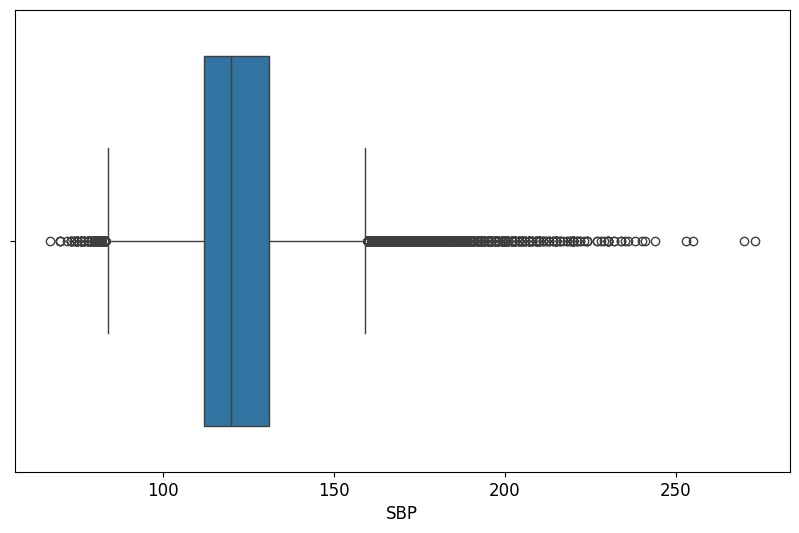

In [49]:
import seaborn as sns
sns.boxplot(df, x='SBP')

In [18]:
# import seaborn as sns


# fig, ax = plt.subplots(24, 1, figsize=(15, 50))

# for i in range(0, len(df_temp := df.drop(['sex', 'DRK_YN'], axis=1).columns)):
    
#     sns.boxplot(df, x=df_temp[i], ax=ax[i])
#     ax[i].set_label(df_temp[i])

# plt.tight_layout()
# plt.show()

### Data Cleaning (20%)

- Handling Missing Values
- Choose appropriate methods to handle missing values (e.g., mean/median imputation for numerical data, mode imputation for categorical data, or deletion of rows/columns).
- Justify your choices for handling missing data.

### Handling Outliers (20%)

- Detect outliers using methods such as the IQR method or Z-score.
- Decide whether to remove, cap, or transform the outliers. Justify your decisions.

In [69]:
from scipy.stats import zscore
z_df = pd.DataFrame()
for feature in df.select_dtypes(include="number"):
    z_df[feature] = zscore(df[feature])

outliers = set()

for i in range(z_df.shape[0]):
    for feature in (dp := dict(z_df.iloc[i, :])):
        if abs(dp[feature]) > 5:  # threshold = 3 (can tweak)
            outliers.add(i)

In [71]:
len(outliers)

77368

In [37]:
Qs = dict()

for feature in df.columns:
    if feature in ['sex', 'DRK_YN', 'SBP']:
        continue
    
    Q1 = np.percentile(df[feature], 25, interpolation = 'midpoint') 
    Q2 = np.percentile(df[feature], 50, interpolation = 'midpoint') 
    Q3 = np.percentile(df[feature], 75, interpolation = 'midpoint')
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    Qs[f'{feature}'] = [Q1, Q2, Q3, IQR, lower_limit, upper_limit]

In [38]:
outliers = set()

for i in range(df.shape[0]):
    for feature in (dp := dict(df.iloc[i, :])):
        if feature in ['sex', 'DRK_YN', 'SBP']:
            continue
        if dp[feature] < Qs[feature][4] or dp[feature] > Qs[feature][5]:
            outliers.add(i)
        
print(len(outliers))

349632


In [59]:
# Log transform

from sklearn.preprocessing import PowerTransformer

# df_log = df.drop(['sex', 'DRK_YN'], axis=1).apply(np.sqrt)


pt = PowerTransformer(method="yeo-johnson")
df_transformed = pt.fit_transform(df.select_dtypes(include="number"))

In [63]:
cols = [x for x in df.columns if x not in ['sex', 'DRK_YN']]

In [64]:
df_log = pd.DataFrame(df_transformed, columns=cols)

In [65]:
Qs_log = dict()

for feature in df_log.columns:
    
    Q1 = np.percentile(df_log[feature], 25, interpolation = 'midpoint') 
    Q2 = np.percentile(df_log[feature], 50, interpolation = 'midpoint') 
    Q3 = np.percentile(df_log[feature], 75, interpolation = 'midpoint')
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    Qs_log[f'{feature}'] = [Q1, Q2, Q3, IQR, lower_limit, upper_limit]

In [66]:
outliers_log = set()

for i in range(df_log.shape[0]):
    for feature in (dp := dict(df_log.iloc[i, :])):
        if dp[feature] < Qs_log[feature][4] or dp[feature] > Qs_log[feature][5]:
            outliers_log.add(i)
        
print(len(outliers_log))

234156


### Data Transformation (30%)

- Encoding Categorical Data
  - Apply label encoding or one-hot encoding to transform categorical data into numerical form.
  - Justify your choice of encoding method.
- Feature Scaling
  - Apply feature scaling techniques such as normalization (Min-Max scaling) or standardization (Z-score normalization) to the dataset.
  - Explain why feature scaling is necessary and how it impacts the model.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, LabelBinarizer

### Data Splitting (10%)

- Split the preprocessed dataset into training and testing sets. Typically, an 80-20 or 70-30 split is used.
- Explain the importance of splitting the data and how it prevents overfitting.

In [1]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(['DRK_YN'], axis=1), df['DRK_YN'], random_state=0, test_size=.20)

### Apply Dimensionality Reduction Techniques (Optional, 10%)

Bonus Task: Apply dimensionality reduction techniques such as Principal Component Analysis (PCA) and discuss how it affects the dataset.